In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn

data_path = '../../../data/mujoco'
model_path = '../../../models/mujoco/walker2d'
result_path = '../../../results/mujoco'

### Creating baseline dataset

In [2]:
data_nsample = 918
data = util_data.read_datafile(f'{data_path}/walker2d_baseline_0', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 17
act_ndim = 6
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

read data shape: torch.Size([80, 918, 23])
read observations shape: torch.Size([80, 918, 17])
read actions shape: torch.Size([80, 918, 6])
shape of observations for training: torch.Size([80, 917, 17])
shape of next observations for training: torch.Size([80, 917, 17])
shape of actions for training: torch.Size([80, 917, 6])


In [3]:
model = example_mujoco.global_dynamics(obs_ndim=obs_ndim, act_ndim=act_ndim)

load_pretrained = True

if load_pretrained:
    # --! load trained weights into the model
    model_path = f'{model_path}/global_checkpoint.pth'
    model.load_state_dict(torch.load(model_path, weights_only=True))

else:
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = torch.nn.MSELoss()

    num_epochs = 1_000

    for epoch in range(num_epochs):
        total_loss = 0.0

        for s, a, s_delta in dataloader:
            pred = model(s, a)
            loss = loss_fn(pred, s_delta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"epoch {epoch}, loss: {total_loss / len(dataloader):.6f}")

    torch.save(model.state_dict(), f'{model_path}/global_checkpoint.pth')

# Evaluating global baseline

In [4]:
eval_data = util_data.read_datafile(f'{data_path}/walker2d_eval_0', data_nsample)
print(f'read evaluation data shape: {eval_data.shape}')

eval_obs, eval_act = torch.split(eval_data, [obs_ndim, act_ndim], dim=-1)
print(f'read evaluation observations shape: {eval_obs.shape}')
print(f'read evaluation actions shape: {eval_act.shape}')

# --! normalize evaluation data
eval_obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

read evaluation data shape: torch.Size([30, 918, 23])
read evaluation observations shape: torch.Size([30, 918, 17])
read evaluation actions shape: torch.Size([30, 918, 6])


In [5]:
model.eval()
util_nn.freeze_module(model)

reanchor_nsample = 1_000
this_traj = 0

s0 = eval_obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_global(model, s0, eval_obs[this_traj], eval_act[this_traj], reset_nsample=reanchor_nsample)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 17])


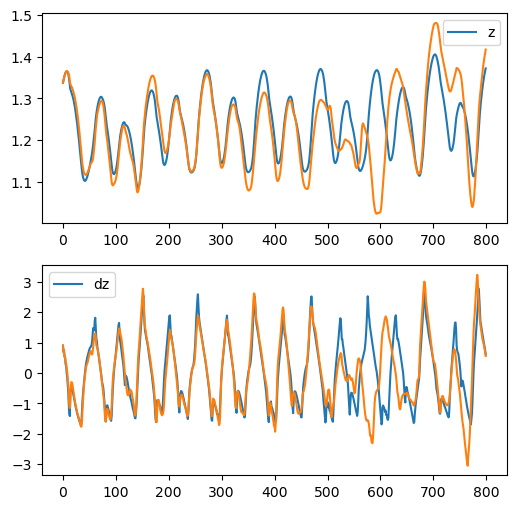

In [6]:
disp_end = 800
datasaved = False

with torch.no_grad():
    plot_rollout_traj = torch.unsqueeze(rollout_traj, 0)
    plot_rollout_traj = torch.cat([
        example_mujoco.denormalize_standard(
            s, mean, std) for s, mean, std in zip(torch.split(plot_rollout_traj, 1, dim=-1), obs_mean, obs_std)], dim=-1)
    plot_obs = torch.cat([
        example_mujoco.denormalize_standard(
            s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

    plt.figure(figsize=(6,6))

    plt.subplot(2,1,1)
    plt.plot(plot_obs[this_traj, :disp_end, 0], label='z')
    plt.plot(plot_rollout_traj[0, :disp_end, 0])
    plt.legend()

    plt.subplot(2,1,2)
    plt.plot(plot_obs[this_traj, :disp_end, 9], label='dz')
    plt.plot(plot_rollout_traj[0, :disp_end, 9])
    plt.legend()

    plt.show()

    if datasaved:
        save_step = torch.arange(obs.shape[1]).reshape(1, -1, 1)
        savedata = np.concatenate([
            save_step[:1, :disp_end, :1],
            plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [9]],
            plot_rollout_traj[:1, :disp_end, :1], plot_rollout_traj[:1, :disp_end, [9]]], axis=2)
        util_data.write_datafile(f'{result_path}/walker2d_global_rollout', savedata, delim=' ')

In [7]:
traj_mse = []
with torch.no_grad():
    for j in range(eval_obs.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {eval_obs.shape[0]}')
        mse = []
        for h in range(1, eval_obs.shape[1]): # horizon
            s0 = eval_obs[j, 0]
            cmp_rollout = example_mujoco.rollout_global(
                model, s0,
                eval_obs[j, :h], eval_act[j, :h],
                reset_nsample=reanchor_nsample)

            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)
            loss = F.mse_loss(cmp_rollout, cmp_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {obs.shape[1]}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)

processing trajectory 1 out of 30
	horizon 100 out of 918, loss: 13.781339645385742
	horizon 200 out of 918, loss: 14.766387939453125
	horizon 300 out of 918, loss: 14.153950691223145
	horizon 400 out of 918, loss: 14.170710563659668
	horizon 500 out of 918, loss: 14.348852157592773
	horizon 600 out of 918, loss: 14.548293113708496
	horizon 700 out of 918, loss: 14.265711784362793
	horizon 800 out of 918, loss: 13.66277027130127
	horizon 900 out of 918, loss: 12.958888053894043
processing trajectory 2 out of 30
	horizon 100 out of 918, loss: 17.058902740478516
	horizon 200 out of 918, loss: 18.392608642578125
	horizon 300 out of 918, loss: 19.250974655151367
	horizon 400 out of 918, loss: 19.222673416137695
	horizon 500 out of 918, loss: 19.35239601135254
	horizon 600 out of 918, loss: 19.466293334960938
	horizon 700 out of 918, loss: 18.252897262573242
	horizon 800 out of 918, loss: 17.605764389038086
	horizon 900 out of 918, loss: 17.263883590698242
processing trajectory 3 out of 30


tensor(4.3259)
tensor(2.8328)


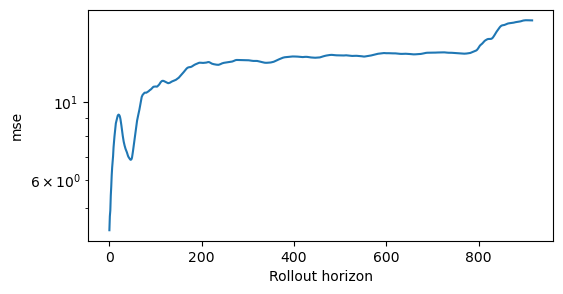

In [8]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.xlabel('Rollout horizon')
    plt.ylabel('mse')
    plt.show()

datasaved = False
if datasaved:
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_global_mse', savedata, delim=' ')